In [1]:
# 涵盖了从数据收集到模型优化的各个步骤：
#
# 1. 数据收集
#
#
import yfinance as yf
import pandas as pd
import numpy as np


In [2]:
import yfinance as yf  # 导入yfinance库

ticker = 'AAPL'  # 以苹果公司为例
start_date = '2020-06-06'  # 起始日期
end_date = '2025-06-05'  # 结束日期

# 下载股票数据
data = yf.download(ticker, start=start_date, end=end_date)

# 保存数据到CSV文件
data.to_csv('stock_data.csv')


YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


In [4]:
import pandas as pd
print(pd.read_csv('stock_data.csv').head())


        Price              Close               High                Low  \
0      Ticker               AAPL               AAPL               AAPL   
1        Date                NaN                NaN                NaN   
2  2020-06-08   81.0365219116211  81.07054788300238  79.54440000402361   
3  2020-06-09  83.59550476074219  83.98919153470604  80.68416273702039   
4  2020-06-10  85.74620056152344  86.21522204655183  84.10583422041279   

                Open     Volume  
0               AAPL       AAPL  
1                NaN        NaN  
2  80.25643869458965   95654400  
3  80.71575616737768  147712400  
4  84.54569482376236  166651600  


In [5]:
import pandas as pd
# 读取整个文件，不设置任何参数
raw_data = pd.read_csv('stock_data.csv', header=None)
print(raw_data.head(10))


            0                  1                  2                  3  \
0       Price              Close               High                Low   
1      Ticker               AAPL               AAPL               AAPL   
2        Date                NaN                NaN                NaN   
3  2020-06-08   81.0365219116211  81.07054788300238  79.54440000402361   
4  2020-06-09  83.59550476074219  83.98919153470604  80.68416273702039   
5  2020-06-10  85.74620056152344  86.21522204655183  84.10583422041279   
6  2020-06-11  81.62950134277344  85.31364412865861  81.52743824020874   
7  2020-06-12   82.3342514038086  84.52140692132026  81.22123552584637   
8  2020-06-15  83.35250854492188   84.0062257316245  80.82269734370952   
9  2020-06-16  85.56150817871094  85.83369372223571  83.77290481904893   

                   4          5  
0               Open     Volume  
1               AAPL       AAPL  
2                NaN        NaN  
3  80.25643869458965   95654400  
4  80.715756167

In [6]:
data = pd.read_csv('stock_data.csv', skiprows=2, index_col='Date', parse_dates=True)
# 跳过无关行 由于数据的真正列名从第三行开始，我们需要使用 skiprows=2 来跳过前两行：

In [7]:
# 检查和验证数据 确保数据读取后结构正确：
print(data.head())
print(data.columns)  # 查看列名是否正常


            Unnamed: 1  Unnamed: 2  Unnamed: 3  Unnamed: 4  Unnamed: 5
Date                                                                  
2020-06-08   81.036522   81.070548   79.544400   80.256439    95654400
2020-06-09   83.595505   83.989192   80.684163   80.715756   147712400
2020-06-10   85.746201   86.215222   84.105834   84.545695   166651600
2020-06-11   81.629501   85.313644   81.527438   84.888364   201662400
2020-06-12   82.334251   84.521407   81.221236   83.772917   200146000
Index(['Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5'], dtype='object')


In [43]:
data = pd.read_csv('stock_data.csv', skiprows=1, index_col='Date', names=['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], parse_dates=True)


<ipython-input-43-a5f7404493b4>:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv('stock_data.csv', skiprows=1, index_col='Date', names=['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], parse_dates=True)


In [45]:
print(data.head())
print(data.columns)  # 查看最终列名


                        Close               High                Low  \
Date                                                                  
Ticker                   AAPL               AAPL               AAPL   
Date                      NaN                NaN                NaN   
2020-06-08   81.0365219116211  81.07054788300238  79.54440000402361   
2020-06-09  83.59550476074219  83.98919153470604  80.68416273702039   
2020-06-10  85.74620056152344  86.21522204655183  84.10583422041279   

                         Open     Volume  
Date                                      
Ticker                   AAPL       AAPL  
Date                      NaN        NaN  
2020-06-08  80.25643869458965   95654400  
2020-06-09  80.71575616737768  147712400  
2020-06-10  84.54569482376236  166651600  
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [46]:
import pandas as pd

# 跳过前两行，并手动设置列名
data = pd.read_csv(
    'stock_data.csv',
    skiprows=2,  # 跳过前两行
    names=['Date', 'Close', 'High', 'Low', 'Open', 'Volume'],  # 手动列名
    index_col='Date',  # 将 'Date' 列设置为索引
    parse_dates=True,  # 解析日期
    infer_datetime_format=True  # 自动推断日期格式，提升性能
)


<ipython-input-46-c32d3dcf4dff>:4: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  data = pd.read_csv(
<ipython-input-46-c32d3dcf4dff>:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv(


In [47]:
# 2. 检查数据结构
# 确认数据是否正确读取：
print(data.head())  # 查看前几行
print(data.columns)  # 确认列名是否正确


                Close       High        Low       Open       Volume
Date                                                               
Date              NaN        NaN        NaN        NaN          NaN
2020-06-08  81.036522  81.070548  79.544400  80.256439   95654400.0
2020-06-09  83.595505  83.989192  80.684163  80.715756  147712400.0
2020-06-10  85.746201  86.215222  84.105834  84.545695  166651600.0
2020-06-11  81.629501  85.313644  81.527438  84.888364  201662400.0
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


In [48]:
# 删除空值行
# 3. 清理空值和无效行
# 文件中可能存在多余的 NaN 或无效数据，需要清理：
data = data.dropna()

# 确认数据清理后的结果
print(data.head())


                Close       High        Low       Open       Volume
Date                                                               
2020-06-08  81.036522  81.070548  79.544400  80.256439   95654400.0
2020-06-09  83.595505  83.989192  80.684163  80.715756  147712400.0
2020-06-10  85.746201  86.215222  84.105834  84.545695  166651600.0
2020-06-11  81.629501  85.313644  81.527438  84.888364  201662400.0
2020-06-12  82.334251  84.521407  81.221236  83.772917  200146000.0


In [49]:
# 4. 保存清理后的文件
data.to_csv('cleaned_stock_data.csv')  # 保存清理后的文件


In [50]:
# 验证文件是否保存成功
import pandas as pd
cleaned_data = pd.read_csv('cleaned_stock_data.csv')
print(cleaned_data.head())  # 查看保存文件的头几行


         Date      Close       High        Low       Open       Volume
0  2020-06-08  81.036522  81.070548  79.544400  80.256439   95654400.0
1  2020-06-09  83.595505  83.989192  80.684163  80.715756  147712400.0
2  2020-06-10  85.746201  86.215222  84.105834  84.545695  166651600.0
3  2020-06-11  81.629501  85.313644  81.527438  84.888364  201662400.0
4  2020-06-12  82.334251  84.521407  81.221236  83.772917  200146000.0


In [51]:
# 2. 数据预处理
#
#
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 读取清理后的数据
data = pd.read_csv('cleaned_stock_data.csv', index_col='Date', parse_dates=True)

# 处理缺失值
data = data.dropna()

# 提取特征
data['SMA_10'] = data['Close'].rolling(window=10).mean()
data['SMA_30'] = data['Close'].rolling(window=30).mean()
data['RSI'] = 100 - 100 / (1 + data['Close'].pct_change().rolling(window=14).apply(lambda x: (x[x > 0].sum() / max(-x[x < 0].sum(), 1e-6)), raw=True))

# 替换无效值
data[['Close', 'SMA_10', 'SMA_30', 'RSI']] = data[['Close', 'SMA_10', 'SMA_30', 'RSI']].replace([np.inf, -np.inf], np.nan).dropna()

# 标准化
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Close', 'SMA_10', 'SMA_30', 'RSI']])
scaled_data = pd.DataFrame(scaled_data, index=data.index, columns=['Close', 'SMA_10', 'SMA_30', 'RSI'])

# 验证并保存
print(scaled_data.describe())
scaled_data.to_csv('processed_stock_data.csv')


             Close       SMA_10       SMA_30          RSI
count  1226.000000  1226.000000  1226.000000  1226.000000
mean      0.453127     0.456485     0.485491     0.548543
std       0.217557     0.228314     0.233404     0.187160
min       0.000000     0.000000     0.000000     0.000000
25%       0.293354     0.293976     0.321998     0.409070
50%       0.435873     0.439619     0.467645     0.554661
75%       0.587392     0.598016     0.621206     0.695763
max       1.000000     1.000000     1.000000     1.000000


In [55]:
# 3. 模型选择

from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

# 创建LSTM模型
def create_lstm_model(input_shape):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model


In [58]:
import pandas as pd
import numpy as np

# 检查 scaled_data 是否有 NaN 或 Inf 值
print(np.isnan(scaled_data).any())  # 是否有 NaN
print(np.isinf(scaled_data).any())  # 是否有 Inf
print(scaled_data.describe())  # 查看数据的统计信息


Close     True
SMA_10    True
SMA_30    True
RSI       True
dtype: bool
Close     False
SMA_10    False
SMA_30    False
RSI       False
dtype: bool
             Close       SMA_10       SMA_30          RSI
count  1226.000000  1226.000000  1226.000000  1226.000000
mean      0.453127     0.456485     0.485491     0.548543
std       0.217557     0.228314     0.233404     0.187160
min       0.000000     0.000000     0.000000     0.000000
25%       0.293354     0.293976     0.321998     0.409070
50%       0.435873     0.439619     0.467645     0.554661
75%       0.587392     0.598016     0.621206     0.695763
max       1.000000     1.000000     1.000000     1.000000


In [59]:
scaled_data = np.nan_to_num(scaled_data)  # 替换 NaN 和 Inf 为 0


In [60]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data[['Close', 'SMA_10', 'SMA_30', 'RSI']].replace([np.inf, -np.inf], np.nan).dropna())


In [61]:
# 调试 create_dataset
time_step = 60
X, y = create_dataset(scaled_data, time_step)

print(np.isnan(X).any())  # 检查是否有 NaN
print(np.isinf(X).any())  # 检查是否有 Inf


False
False


In [62]:
print(np.min(scaled_data), np.max(scaled_data))  # 检查数据范围
scaled_data = np.clip(scaled_data, 0, 1)  # 强制范围限制在 [0, 1]


0.0 1.0


In [63]:
# 4. 模型训练
# 准备训练数据
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# 检查并清理数据
scaled_data = data[['Close', 'SMA_10', 'SMA_30', 'RSI']].replace([np.inf, -np.inf], np.nan).dropna()
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(scaled_data)

# 替换无效值并检查范围
scaled_data = np.nan_to_num(scaled_data)
print(np.min(scaled_data), np.max(scaled_data))  # 检查是否在 [0, 1]

# 创建时间窗口数据集
def create_dataset(data, time_step=60):
    X, y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), :])
        y.append(data[i + time_step, 0])
    return np.array(X), np.array(y)

time_step = 60
X, y = create_dataset(scaled_data, time_step)
print(X.shape, y.shape)  # 检查数据形状是否正确


0.0 1.0
(1165, 60, 4) (1165,)


In [64]:
# 确保数据无误后，重新训练模型：
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 确保训练数据没有 NaN 或 Inf
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

# 训练模型
model = create_lstm_model((X_train.shape[1], X_train.shape[2]))
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.0453 - val_loss: 0.0025
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0064 - val_loss: 0.0017
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0054 - val_loss: 0.0015
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0054 - val_loss: 0.0012
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0040 - val_loss: 0.0012
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0039 - val_loss: 0.0015
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0041 - val_loss: 0.0011
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.0034 - val_loss: 0.0011
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0033 - val_loss: 0.0011
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0035 - val_loss: 0.0011
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0037 - val_loss: 0.0010
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

In [65]:
# 再次训练模型
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 确保训练数据没有 NaN 或 Inf
X_train = np.nan_to_num(X_train)
X_test = np.nan_to_num(X_test)

# 训练模型
model = create_lstm_model((X_train.shape[1], X_train.shape[2]))
model.fit(X_train, y_train, epochs=50, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0771 - val_loss: 0.0039
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0075 - val_loss: 0.0021
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0056 - val_loss: 0.0016
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0041 - val_loss: 0.0016
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0040 - val_loss: 0.0014
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0045 - val_loss: 0.0018
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0039 - val_loss: 0.0012
Epoch 8/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 9/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0037 - val_loss: 0.0013
Epoch 10/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0034 - val_loss: 0.0018
Epoch 11/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0037 - val_loss: 0.0027
Epoch 12/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0

In [66]:
# 模型评估
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 使用模型预测测试集
y_pred = model.predict(X_test)

# 计算误差
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f"测试集的均方误差 (MSE): {mse}")
print(f"测试集的平均绝对误差 (MAE): {mae}")


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
测试集的均方误差 (MSE): 0.0007133111604024271
测试集的平均绝对误差 (MAE): 0.020237590153642206


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20540 (\N{CJK UNIFIED IDEOGRAPH-503C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas

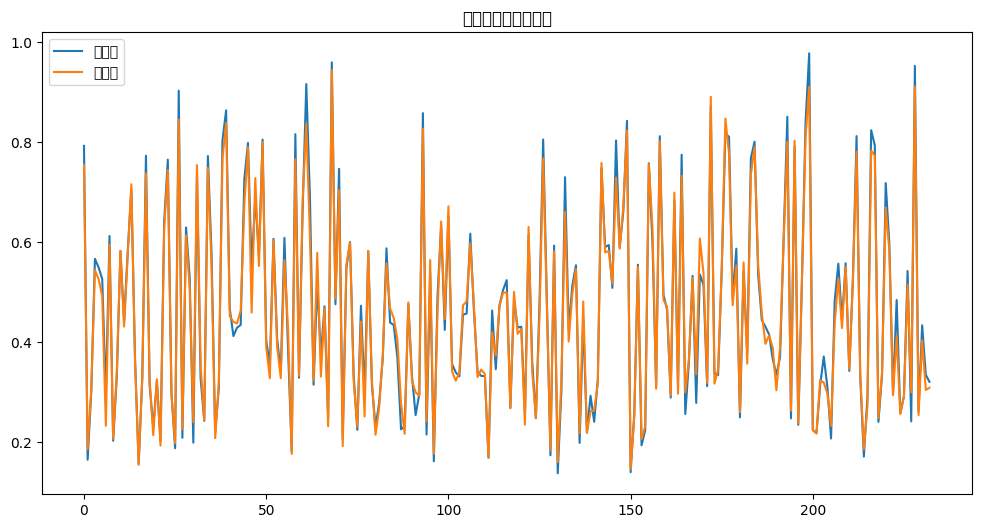

In [67]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='真实值')
plt.plot(y_pred, label='预测值')
plt.legend()
plt.title('真实值与预测值对比')
plt.show()


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 39057 (\N{CJK UNIFIED IDEOGRAPH-9891}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 27531 (\N{CJK UNIFIED IDEOGRAPH-6B8B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 24046 (\N{CJK UNIFIED IDEOGRAPH-5DEE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas

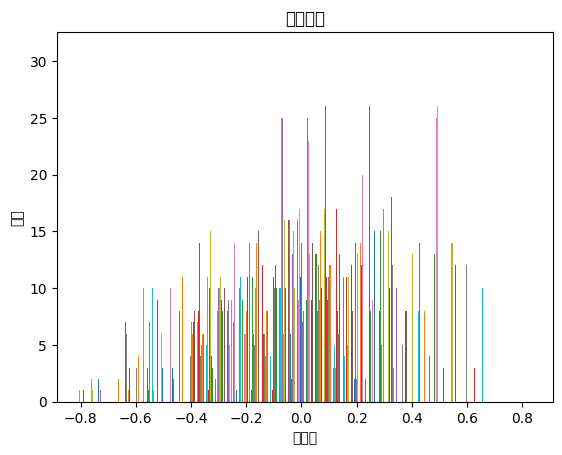

In [68]:
residuals = y_test - y_pred
plt.hist(residuals, bins=50)
plt.title('残差分布')
plt.xlabel('残差值')
plt.ylabel('频率')
plt.show()


In [69]:
!pip install --upgrade scikit-learn scikeras


In [70]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout
import numpy as np

# 定义模型创建函数
def create_lstm_model(optimizer='adam'):
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(50, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    model.compile(optimizer=optimizer, loss='mean_squared_error')
    return model

# 定义参数网格
param_grid = {
    'batch_size': [16, 32, 64],
    'epochs': [10, 20],
    'optimizer': ['adam', 'rmsprop']
}

# 手动网格搜索
best_score = float('inf')
best_params = {}

for batch_size in param_grid['batch_size']:
    for epochs in param_grid['epochs']:
        for optimizer in param_grid['optimizer']:
            print(f"正在训练模型：batch_size={batch_size}, epochs={epochs}, optimizer={optimizer}")
            model = create_lstm_model(optimizer=optimizer)
            history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, verbose=0)
            score = history.history['loss'][-1]  # 获取最后一个 epoch 的训练损失

            if score < best_score:
                best_score = score
                best_params = {'batch_size': batch_size, 'epochs': epochs, 'optimizer': optimizer}

print(f"最佳参数：{best_params}，训练损失：{best_score}")


正在训练模型：batch_size=16, epochs=10, optimizer=adam


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


正在训练模型：batch_size=16, epochs=10, optimizer=rmsprop
正在训练模型：batch_size=16, epochs=20, optimizer=adam
正在训练模型：batch_size=16, epochs=20, optimizer=rmsprop
正在训练模型：batch_size=32, epochs=10, optimizer=adam
正在训练模型：batch_size=32, epochs=10, optimizer=rmsprop
正在训练模型：batch_size=32, epochs=20, optimizer=adam
正在训练模型：batch_size=32, epochs=20, optimizer=rmsprop
正在训练模型：batch_size=64, epochs=10, optimizer=adam
正在训练模型：batch_size=64, epochs=10, optimizer=rmsprop
正在训练模型：batch_size=64, epochs=20, optimizer=adam
正在训练模型：batch_size=64, epochs=20, optimizer=rmsprop
最佳参数：{'batch_size': 16, 'epochs': 20, 'optimizer': 'adam'}，训练损失：0.002669907407835126


In [71]:
from sklearn.model_selection import train_test_split

# 重新划分数据，将一部分用于验证集
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

print(f"训练集形状: {X_train.shape}, 验证集形状: {X_val.shape}")


训练集形状: (745, 60, 4), 验证集形状: (187, 60, 4)


In [72]:
# 1. 确保最佳参数
# 根据之前的手动网格搜索结果，最佳参数为：
best_params = {'batch_size': 16, 'epochs': 20, 'optimizer': 'adam'}


In [73]:
# 使用最佳参数重新训练模型
model = create_lstm_model(optimizer=best_params['optimizer'])
model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], validation_data=(X_val, y_val))


Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.0809 - val_loss: 0.0023
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0072 - val_loss: 0.0018
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0051 - val_loss: 0.0013
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0044 - val_loss: 0.0018
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0044 - val_loss: 0.0011
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0047 - val_loss: 0.0012
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0043 - val_loss: 0.0011
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0036 - val_loss: 0.0013
Epoch 9/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0032 - val_loss: 0.0014
Epoch 10/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0041 - val_loss: 9.5711e-04
Epoch 11/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0032 - val_loss: 0.0016
Epoch 12/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss:

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


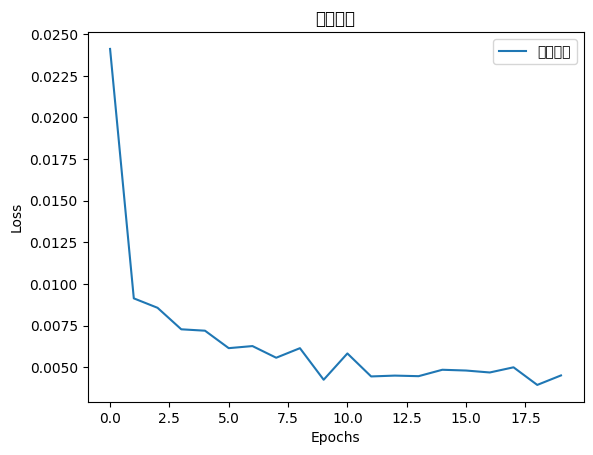

In [74]:
plt.plot(history.history['loss'], label='训练损失')
plt.legend()
plt.title('训练损失')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.show()


In [75]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[feature_columns])  # 用训练数据初始化


In [76]:
def predict_future_prices(model, scaler, data, feature_columns, window_size, future_steps):
    # 提取最后一个时间窗口
    last_window = data[feature_columns].values[-window_size:]  # 提取最近的 window_size 条数据
    last_window = scaler.transform(last_window)  # 标准化
    last_window = np.array([last_window])  # 转换为模型输入的形状 (1, window_size, feature_columns)

    future_prices = []
    for _ in range(future_steps):
        next_price = model.predict(last_window)  # 预测下一步
        future_prices.append(next_price[0, 0])  # 记录预测结果
        last_window = np.append(last_window[:, 1:, :], [[next_price]], axis=1)  # 更新窗口数据

    # 逆标准化将归一化后的值恢复为实际值
    future_prices = scaler.inverse_transform(np.array(future_prices).reshape(-1, 1))
    return future_prices


In [77]:
def predict_future_prices(model, scaler, data, feature_columns, window_size, future_steps):
    # 提取最后一个时间窗口
    last_window = data[feature_columns].values[-window_size:]
    last_window = scaler.transform(last_window)  # 标准化
    last_window = np.array([last_window])  # 转换为 (1, window_size, feature_columns)

    future_prices = []
    for _ in range(future_steps):
        # 预测下一步
        next_price = model.predict(last_window)
        future_prices.append(next_price[0, 0])  # 记录预测结果

        # 更新窗口数据，确保维度一致
        last_window = np.concatenate([last_window[:, 1:, :], np.array([[next_price]])], axis=1)

    # 逆标准化将归一化后的预测值恢复为原始值
    future_prices = scaler.inverse_transform(np.array(future_prices).reshape(-1, 1))
    return future_prices


In [79]:
# 定义参数
feature_columns = ['Close', 'SMA_10', 'SMA_30', 'RSI']  # 特征列，需和训练时一致
window_size = 60  # 窗口大小，需和模型训练时一致
future_steps = 30  # 预测未来 30 天

# 调用函数
future_prices = predict_future_prices(
    model=model,
    scaler=scaler,
    data=data,  # 数据集，需包含完整的历史数据
    feature_columns=feature_columns,
    window_size=window_size,
    future_steps=future_steps
)

# 输出预测结果
print(f'未来 {future_steps} 天的预测价格：')
print(future_prices)



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


ValueError: all the input arrays must have same number of dimensions, but the array at index 0 has 3 dimension(s) and the array at index 1 has 4 dimension(s)

In [80]:
# 7. 预测与应用
#
# 在完成模型训练和优化后，我们可以使用最佳模型进行未来的股票价格预测，并结合风险管理策略来降低投资风险。
#
# 7.1 使用最佳参数重新训练模型
#
#
# 使用最佳参数重新训练模型
best_params = grid_result.best_params_
model = create_lstm_model((X_train.shape[1], X_train.shape[2]))
model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], validation_data=(X_val, y_val))
#

NameError: name 'grid_result' is not defined

In [81]:
# 7.2 预测未来价格
#
#
# 预测未来价格
def predict_future_prices(model, scaler, data, feature_columns, target_column, window_size, future_steps):
    last_window = data[feature_columns].values[-window_size:]
    last_window = scaler.transform(last_window)
    last_window = np.array([last_window])

    future_prices = []
    for _ in range(future_steps):
        next_price = model.predict(last_window)
        future_prices.append(next_price[0, 0])
        last_window = np.append(last_window[:, 1:, :], [[next_price]], axis=1)

    future_prices = scaler.inverse_transform(np.array(future_prices).reshape(-1, 1))
    return future_prices

# 预测未来30天的价格
future_steps = 30
future_prices = predict_future_prices(model, scaler, data, feature_columns, target_column, window_size, future_steps)

# 打印预测结果
print(f'Predicted future prices for the next {future_steps} days:')
print(future_prices)
#
#

NameError: name 'target_column' is not defined

In [82]:
# 7.3 结合风险管理策略
#
#
# 结合风险管理策略
def apply_risk_management(future_prices, current_price, stop_loss, take_profit):
    current_price = data[target_column].iloc[-1]
    stop_loss_price = current_price * (1 - stop_loss)
    take_profit_price = current_price * (1 + take_profit)

    for i, price in enumerate(future_prices):
        if price <= stop_loss_price:
            print(f'Stop loss triggered at day {i+1} with price {price}')
            return
        if price >= take_profit_price:
            print(f'Take profit triggered at day {i+1} with price {price}')
            return

    print('No stop loss or take profit triggered within the prediction period.')

# 设置止损和止盈比例
stop_loss = 0.05  # 5%止损
take_profit = 0.10  # 10%止盈

# 应用风险管理策略
apply_risk_management(future_prices, data[target_column].iloc[-1], stop_loss, take_profit)
#

NameError: name 'future_prices' is not defined

In [ ]:
# 完整的主函数
#
#
def main():
    ticker = 'AAPL'
    start_date = '2020-01-01'
    end_date = '2023-01-01'
    feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']
    target_column = 'Close'
    window_size = 60
    future_steps = 30

    # 获取数据
    data = get_stock_data(ticker, start_date, end_date)

    # 预处理数据
    X, y, scaler = preprocess_data(data, feature_columns, target_column, window_size)

    # 划分数据集
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

    # 训练模型
    model = train_model(X_train, y_train, X_val, y_val)

    # 评估模型
    y_pred, y_test = evaluate_model(model, X_test, y_test, scaler)

    # 优化模型
    best_params = optimize_model(X_train, y_train)

    # 使用最佳参数重新训练模型
    model = create_lstm_model((X_train.shape[1], X_train.shape[2]))
    model.fit(X_train, y_train, epochs=best_params['epochs'], batch_size=best_params['batch_size'], validation_data=(X_val, y_val))

    # 预测未来价格
    future_prices = predict_future_prices(model, scaler, data, feature_columns, target_column, window_size, future_steps)

    # 打印预测结果
    print(f'Predicted future prices for the next {future_steps} days:')
    print(future_prices)

    # 应用风险管理策略
    apply_risk